Required Python Packages

The following Python packages are used in this notebook for data processing, visualisation, API queries, and concurrent processing.

Installation

Run the following command if the required packages are not already installed:

In [1]:
#!pip install pandas matplotlib seaborn requests urllib3

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from concurrent.futures import ThreadPoolExecutor, as_completed

## API Configuration

The Koordinates API settings are defined using the API key, Stats NZ SA2 layer ID, and API URL. The prepared AirBnB and bond datasets are then loaded from the data directory for further analysis.

In [3]:
API_KEY = "63f9121687334581abc4a4671ff722f8"
LAYER_ID = "123515"
URL = "https://koordinates.com/services/query/v1/vector.json"

Dir_path = "../../Data_Wrangling_Datasets"
airbnb_dataset = pd.read_csv(os.path.join(Dir_path, "christchurch_aligned_oct2025_jun2026_combined.csv"))
tenancy_dataset = pd.read_csv(os.path.join(Dir_path, "cleaned_bond_data_aligned.csv"))

print(f"Number of rows in merged dataset: {len(airbnb_dataset)}")
print(f"Merged Dataset Shape: {airbnb_dataset.shape}")

print(f"Number of rows in merged dataset: {len(tenancy_dataset)}")
print(f"Merged Dataset Shape: {tenancy_dataset.shape}")

Number of rows in merged dataset: 28758
Merged Dataset Shape: (28758, 19)
Number of rows in merged dataset: 26991
Merged Dataset Shape: (26991, 12)


## HTTP Session and Retry Logic

A resilient HTTP session is configured to handle temporary Koordinates API failures. The retry mechanism attempts failed requests up to 5 times, with increasing wait times, while the connection pool allows multiple API requests to be handled efficiently.

In [5]:
# Configure a resilient HTTP session with retry logic
session = requests.Session()
retries = Retry(
    total=5,
    backoff_factor=1,  # Waits 1s, 2s, 4s, 8s, 16s between retries
    status_forcelist=[429, 500, 502, 503, 504],
    raise_on_status=False
)
adapter = HTTPAdapter(max_retries=retries, pool_connections=10, pool_maxsize=10)
session.mount("https://", adapter)


## SA2 Information Query

This function sends each AirBnB latitude/longitude pair to the Koordinates API and retrieves the matching **SA2 area name and code**. It also handles API errors and returns missing values when no matching area is found.

In [6]:
def get_sa2_info(lat, lon):
    # Parameters required to query the Koordinates SA2 layer
    params = {
        "key": API_KEY,
        "layer": LAYER_ID,
        "x": lon,
        "y": lat,
        "max_results": 1,
        "radius": 1000
    }
    
    try:
        # Send the coordinate query to the Koordinates API
        res = session.get(URL, params=params, timeout=15)
        
        # Process the response if the request was successful
        if res.status_code == 200:
            data = res.json()
            # Extract matching SA2 features from the API response
            features = data.get("vectorQuery", {}).get("layers", {}).get(LAYER_ID, {}).get("features", [])
            if features:
                # Extract the SA2 name and code from the first matching feature
                props = features[0].get("properties", {})
                return {
                    "latitude": lat,
                    "longitude": lon,
                    "area_name": props.get("SA22026_V1_00_NAME"),
                    "sa2_code": str(props.get("SA22026_V1_00"))
                }
    except Exception as e:
        # Report errors without stopping the remaining queries
        print(f"Failed query for ({lat}, {lon}): {e}")
        
     # Return missing values if no matching SA2 area is found
    return {"latitude": lat, "longitude": lon, "area_name": None, "sa2_code": None}


In [17]:
# Extract unique coordinates to drastically reduce total API calls
unique_coords = airbnb_dataset[['latitude', 'longitude']].drop_duplicates()
print(f"Total rows: {len(airbnb_dataset)} | Unique coordinate pairs to query: {len(unique_coords)}")


Total rows: 28758 | Unique coordinate pairs to query: 3956


## Concurrent API Requests
To fetch area information efficiently without hitting API rate limits or overloading the server, we execute requests concurrently using `ThreadPoolExecutor`.

- **Concurrency:** Uses a pool of 3 worker threads to process coordinate queries in parallel.
- **List Comprehension:** Submits a `get_sa2_info` task for each unique coordinate pair in `unique_coords`.
- **`as_completed`:** Iterates through tasks as they finish, appending each returned result dictionary to the `results` list.

In [18]:
# Initialize a list to collect API query results
results = []

# Use ThreadPoolExecutor with 3 workers to manage concurrent requests and avoid rate limits
with ThreadPoolExecutor(max_workers=3) as executor:
    # Submit a query task for each unique coordinate pair
    futures = [
        executor.submit(get_sa2_info, row["latitude"], row["longitude"])
        for _, row in unique_coords.iterrows()
    ]

    # Retrieve and store results as individual API calls complete
    for future in as_completed(futures):
        results.append(future.result())

**Note:** Don't run this cell again once the file is created in local.

The dataframe already sitting in your kernel's memory. If you've run the merge cell (cell 12) more than once in this session, airbnb_dataset already has area_name/sa2_code columns baked in from the first run, and merging sa2_lookup_df onto it again creates the _x/_y duplicates — completely independent of whatever file exists on disk.

In [27]:
# Reload the ORIGINAL airbnb dataset fresh, so it has no SA2 columns yet
airbnb_dataset = pd.read_csv(os.path.join(Dir_path, "christchurch_aligned_oct2025_jun2026_combined.csv"))

sa2_lookup_df = pd.DataFrame(results)
airbnb_dataset = airbnb_dataset.merge(sa2_lookup_df, on=['latitude', 'longitude'], how='left')

# now safe to save
output_file = os.path.join(Dir_path, "christchurch_airbnb_with_sa2.csv")
airbnb_dataset.to_csv(output_file, index=False)

In [4]:
airbnb_dataset = pd.read_csv(os.path.join(Dir_path, "christchurch_airbnb_with_sa2.csv"))

In [5]:
# Align data types for join keys
airbnb_dataset['sa2_code'] = airbnb_dataset['sa2_code'].astype(str)
airbnb_dataset.shape


tenancy_dataset['Location Id'] = tenancy_dataset['Location Id'].astype(str)
tenancy_dataset.shape

(26991, 12)

## Data Cleaning & Dataset Merging

To prepare the AirBnB and tenancy datasets for integration:
1. **Key Standardisation (`clean_id`):** Strips trailing decimals (e.g., `'316700.0'` $\rightarrow$ `'316700'`) and whitespace from location ID keys so they match reliably.
2. **Date Conversion:** Converts the `TimeFrame` columns to standard `datetime` format using `dayfirst=True` to ensure accurate date-based matching.
3. **Inner Join:** Merges both datasets on matching cleaned location IDs (`sa2_code_clean` / `Location_Id_clean`) and dates (`TimeFrame_dt`), keeping only records present in both sources.

In [7]:
# Clean and standardize SA2 Code / Location Id strings
def clean_id(val):
    if pd.isna(val):
        return ""
    # Convert floats like '316700.0' or numbers to clean integer strings
    s = str(val).strip()
    if s.endswith('.0'):
        s = s[:-2]
    return s

airbnb_dataset['sa2_code_clean'] = airbnb_dataset['sa2_code'].apply(clean_id)
tenancy_dataset['Location_Id_clean'] = tenancy_dataset['Location Id'].apply(clean_id)

# Convert TimeFrame columns to datetime objects for accurate date matching
airbnb_dataset['TimeFrame_dt'] = pd.to_datetime(airbnb_dataset['TimeFrame'], dayfirst=True, errors='coerce')
tenancy_dataset['TimeFrame_dt'] = pd.to_datetime(tenancy_dataset['TimeFrame'], dayfirst=True, errors='coerce')

# ==============================================================================
# 1. DETAILED / DISAGGREGATED MERGE (Includes all Dwelling & Bedroom breakdowns)
# ==============================================================================
merged_df_detailed = airbnb_dataset.merge(
    tenancy_dataset,
    left_on=['sa2_code_clean', 'TimeFrame_dt'],
    right_on=['Location_Id_clean', 'TimeFrame_dt'],
    how='inner'
)

print(f"Number of rows in detailed merged dataset: {len(merged_df_detailed)}")
print(f"Detailed Merged Dataset Shape: {merged_df_detailed.shape}")

# Save the detailed merged dataset locally
detailed_output_file = os.path.join(Dir_path, "christchurch_airbnb_bond_detailed.csv")
merged_df_detailed.to_csv(detailed_output_file, index=False)
print(f"Saved detailed merged dataset to {detailed_output_file}\n")


# ==============================================================================
# 2. SUMMARY / AGGREGATED MERGE (Includes overall location totals only)
# ==============================================================================
# Filter tenancy dataset to summary rows only ('ALL' Dwelling Type & 'ALL' Number Of Beds)
tenancy_summary = tenancy_dataset[
    (tenancy_dataset['Dwelling Type'].astype(str).str.upper() == 'ALL') & 
    (tenancy_dataset['Number Of Beds'].astype(str).str.upper() == 'ALL')
].copy()

merged_df_summary = airbnb_dataset.merge(
    tenancy_summary,
    left_on=['sa2_code_clean', 'TimeFrame_dt'],
    right_on=['Location_Id_clean', 'TimeFrame_dt'],
    how='inner'
)

print(f"Number of rows in summary merged dataset: {len(merged_df_summary)}")
print(f"Summary Merged Dataset Shape: {merged_df_summary.shape}")

# Save the summary merged dataset locally
summary_output_file = os.path.join(Dir_path, "christchurch_airbnb_bond_summary.csv")
merged_df_summary.to_csv(summary_output_file, index=False)
print(f"Saved summary merged dataset to {summary_output_file}")

Number of rows in detailed merged dataset: 60895
Detailed Merged Dataset Shape: (60895, 36)
Saved detailed merged dataset to ../../Data_Wrangling_Datasets\christchurch_airbnb_bond_detailed.csv

Number of rows in summary merged dataset: 7358
Summary Merged Dataset Shape: (7358, 36)
Saved summary merged dataset to ../../Data_Wrangling_Datasets\christchurch_airbnb_bond_summary.csv


### 1. Median AirBnB Price in Christchurch Central

To find the median daily listing price for Christchurch Central:
1. **Filter by Location ID:** Filter the AirBnB dataset for records matching SA2 code `'326600'` (Christchurch Central).
2. **Calculate Median:** Compute the median value of the `'price'` column to get a central price point robust against extreme outliers.

In [8]:
# 1. Median AirBnB price in Christchurch Central (ID 326600)
cc_airbnb = airbnb_dataset[airbnb_dataset['sa2_code'] == '326600']
median_cc_price = cc_airbnb['price'].median()
print(f"Median Christchurch Central AirBnB Price: ${median_cc_price}")

print(f"Number of rows in merged dataset: {len(cc_airbnb)}")
print(f"Merged Dataset Shape: {cc_airbnb.shape}")

Median Christchurch Central AirBnB Price: $239.0
Number of rows in merged dataset: 1106
Merged Dataset Shape: (1106, 23)


### 2. Rental Price Gap Analysis (Short-Term vs. Long-Term)

To identify which part of Christchurch has the largest gap between short-term AirBnB rentals and long-term residential leases:

1. **Daily Rent Conversion:** Convert weekly bond rental rates (`Median Rent`) to an equivalent daily price by dividing by 7 (`daily_bond_price = Median Rent / 7.0`).
2. **Calculate Price Difference:** Subtract the daily long-term rent from the nightly AirBnB rate (`price - daily_bond_price`) for each record.
3. **Aggregate by Area:** Calculate the median price gap for each suburb/area name and sort in descending order to identify the location with the greatest premium.


### Dataset Granularity Comparison

When executing this calculation, the price gap can be evaluated across two dataset structures:

* **Unfiltered Dataset (`merged_df_detailed`):**
  * **Rows Evaluated:** 60,895
  * **Structure:** Includes specific bedroom count and dwelling type sub-categories (e.g., 1-bed, 2-bed, houses, apartments). Each AirBnB listing joins to multiple tenancy rows, creating a 1-to-many relationship.
  * **Largest Price Gap Area:** **Bryndwr South** ($354.86 daily gap)

* **Filtered Dataset (`merged_df_summary`):**
  * **Rows Evaluated:** 7,358
  * **Structure:** Deduplicated to overall area summary records only (`'ALL'` Dwelling Type and `'ALL'` Number Of Beds). Each AirBnB listing matches exactly once to its local area market rate (1-to-1 relationship).
  * **Largest Price Gap Area:** **Bryndwr South** ($354.86 daily gap)

> **Note on Identical Results:** Both methods return **Bryndwr South** with an identical median gap of **$354.86 per day**. This occurs because duplicating individual listings across sub-categories replicates data points symmetrically around the central value, leaving the median ($50^{\text{th}}$ percentile) unchanged. However, **`merged_df_summary` (7,358 rows)** is the logically correct dataset for macro-level market comparisons as it avoids redundant row duplication.

In [9]:
# ==============================================================================
# CALCULATING DAILY RENT & PRICE GAP
# ==============================================================================

# 1. Unfiltered Merged Dataset (Includes multiple records per SA2 / TimeFrame)
merged_df_detailed['daily_bond_price'] = merged_df_detailed['Median Rent'] / 7.0
merged_df_detailed['price_gap'] = merged_df_detailed['price'] - merged_df_detailed['daily_bond_price']

# 2. Filtered/Deduplicated Merged Dataset (Summary rows only: 'ALL' Dwelling & 'ALL' Bedrooms)
merged_df_summary['daily_bond_price'] = merged_df_summary['Median Rent'] / 7.0
merged_df_summary['price_gap'] = merged_df_summary['price'] - merged_df_summary['daily_bond_price']


# ==============================================================================
# COMPARISON 1: UNFILTERED (MULTIPLE RECORDS / SUB-CATEGORIES INCLUDED)
# ==============================================================================

# Top area by median price gap
gap_unfiltered = merged_df_detailed.groupby('area_name')['price_gap'].median().sort_values(ascending=False)

print("--- 1. UNFILTERED MERGED DATASET (Multiple Sub-Records Included) ---")
print(f"Total Rows Evaluated: {len(merged_df_detailed)}")
print("Area with Largest Price Gap:")
print(gap_unfiltered.head(1))
print("\n" + "="*70 + "\n")


# ==============================================================================
# COMPARISON 2: FILTERED (DEDUPLICATED / SUMMARY RECORD ONLY)
# ==============================================================================

# Top area by median price gap
gap_filtered = merged_df_summary.groupby('area_name')['price_gap'].median().sort_values(ascending=False)

print("--- 2. FILTERED MERGED DATASET (Deduplicated Summary Record Only) ---")
print(f"Total Rows Evaluated: {len(merged_df_summary)}")
print("Area with Largest Price Gap:")
print(gap_filtered.head(1))

--- 1. UNFILTERED MERGED DATASET (Multiple Sub-Records Included) ---
Total Rows Evaluated: 60895
Area with Largest Price Gap:
area_name
Bryndwr South    354.857143
Name: price_gap, dtype: float64


--- 2. FILTERED MERGED DATASET (Deduplicated Summary Record Only) ---
Total Rows Evaluated: 7358
Area with Largest Price Gap:
area_name
Bryndwr South    354.857143
Name: price_gap, dtype: float64


## Visualization: Price Disparity Across Christchurch Suburbs

This section analyzes and visualizes the gap between short-term AirBnB nightly prices and long-term daily rental rates across Christchurch areas:

1. **Daily Rent Normalization:** Converts weekly median bond rent to a daily equivalent rate (`Median Rent / 7.0`) and calculates the daily price premium (`price - daily_bond_rent`).
2. **Filtering Top Suburbs:** Identifies the top 10 suburbs with the largest median price gaps to focus on areas with the most extreme pricing differences.
3. **Distribution Analysis (Boxplot):** Uses Seaborn to display the spread, median, quartiles, and luxury outliers (`showfliers=True`) for each suburb.
4. **Reference Benchmark:** Includes a vertical dashed red line at `$0` to clearly delineate where AirBnB prices exceed traditional long-term daily rents.

C:\Users\Bhuvii\AppData\Local\Temp\ipykernel_32412\4123885601.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


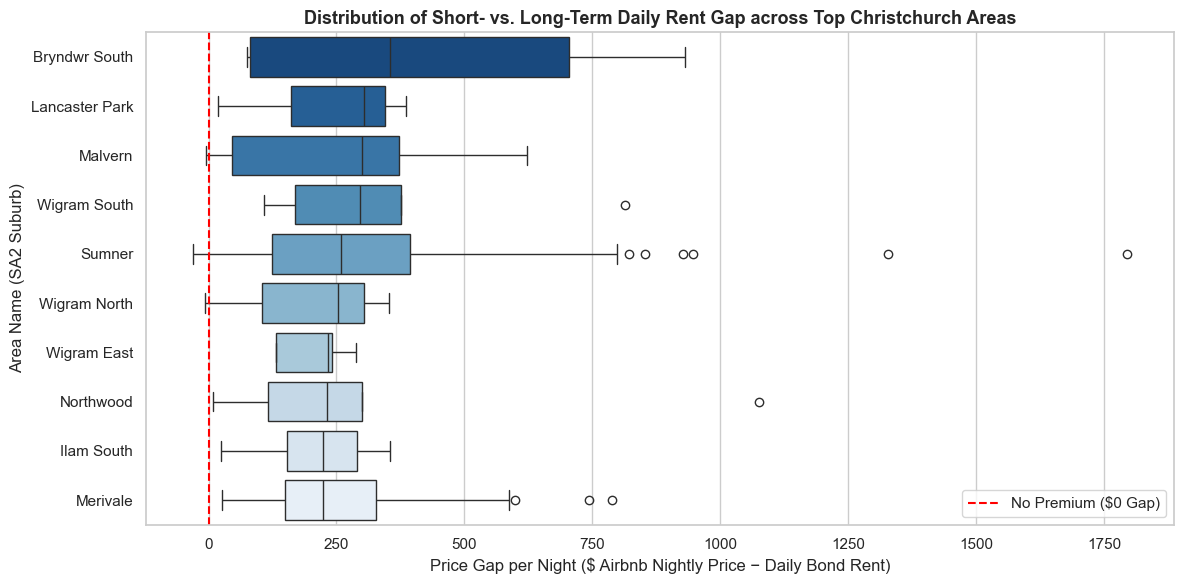

In [12]:
# Set visual style
sns.set_theme(style="whitegrid")

# Filter out areas with fewer than 5 listings
listing_counts = merged_df_summary['area_name'].value_counts()
valid_areas = listing_counts[listing_counts >= 5].index

filtered_df = merged_df_summary[merged_df_summary['area_name'].isin(valid_areas)]

# Extract Top 10 Suburbs from filtered data
top_10_areas = (
    filtered_df.groupby('area_name')['price_gap']
    .median()
    .nlargest(10)
    .index
)
plot_data = filtered_df[filtered_df['area_name'].isin(top_10_areas)]

# 3. Plot Distribution per Location ID / Suburb
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=plot_data, 
    x='price_gap', 
    y='area_name', 
    order=top_10_areas,
    palette="Blues_r",
    showfliers=True  # Display outlier luxury listings
)

# Benchmark Line at $0 (where short-term matches long-term daily rent)
plt.axvline(x=0, color='red', linestyle='--', label='No Premium ($0 Gap)')

plt.title("Distribution of Short- vs. Long-Term Daily Rent Gap across Top Christchurch Areas", fontsize=13, fontweight='bold')
plt.xlabel("Price Gap per Night ($ Airbnb Nightly Price − Daily Bond Rent)")
plt.ylabel("Area Name (SA2 Suburb)")
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### 3. Supply Comparison (AirBnB vs. Long-Term Rentals)

To evaluate property availability and rental composition across areas:
- **`airbnb_count`:** Counts unique AirBnB listing IDs (`id`) per area to measure active short-term supply.
- **`bond_count`:** Extracts the total active rental bond count (`Total Bonds`) per area to measure long-term housing supply.

In [13]:
# 3. Supply comparison (Properties count)
property_counts = merged_df_summary.groupby('area_name').agg(
    airbnb_count=('id', 'nunique'),
    bond_count=('Total Bonds', 'first')
)
print(property_counts)

                 airbnb_count  bond_count
area_name                                
Addington East             17          87
Addington North            20          12
Addington West             35          87
Aidanfield                  7          15
Aranui                      1           9
...                       ...         ...
Wigram South                5          12
Wigram West                 1           9
Woolston East               8          15
Woolston North              7          42
Yaldhurst                  12           9

[119 rows x 2 columns]


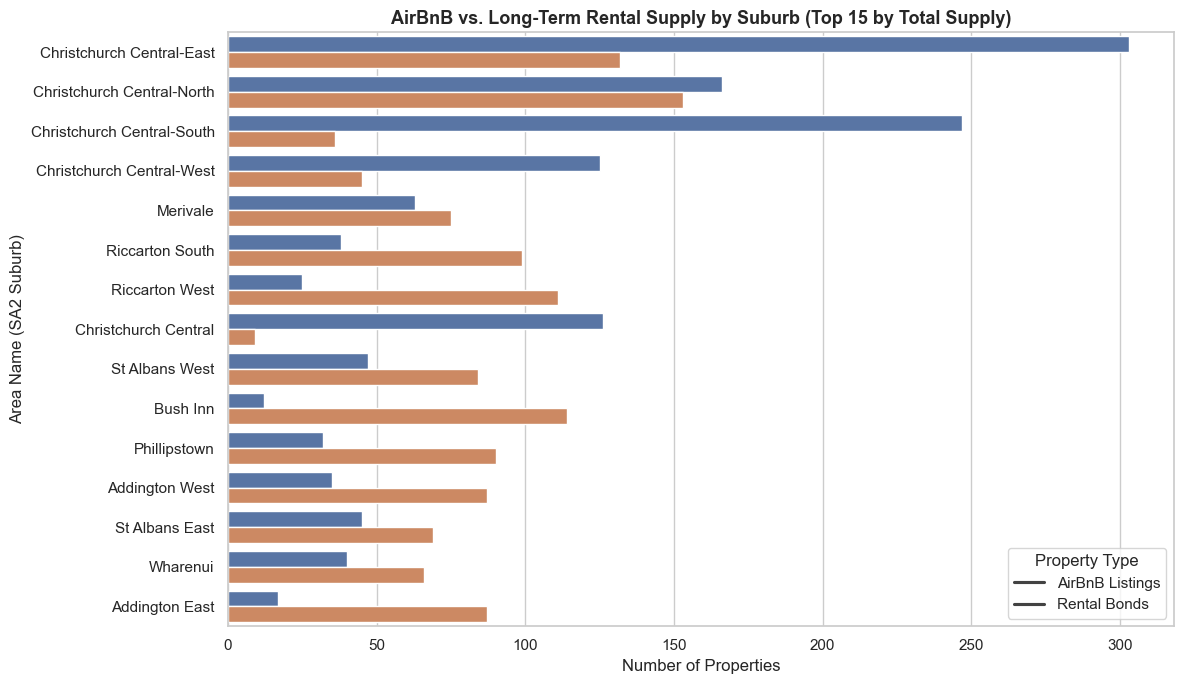

In [14]:
sns.set_theme(style="whitegrid")

# Take the top N suburbs by total supply (AirBnB + bonds) so the chart stays readable
property_counts_sorted = property_counts.copy()
property_counts_sorted['total'] = property_counts_sorted['airbnb_count'] + property_counts_sorted['bond_count']
top_areas = property_counts_sorted.sort_values('total', ascending=False).head(15)

# Reshape to long format for a grouped bar chart
plot_df = top_areas[['airbnb_count', 'bond_count']].reset_index().melt(
    id_vars='area_name', var_name='property_type', value_name='count'
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=plot_df,
    y='area_name', x='count', hue='property_type',
    palette={'airbnb_count': '#4C72B0', 'bond_count': '#DD8452'}
)

plt.title("AirBnB vs. Long-Term Rental Supply by Suburb (Top 15 by Total Supply)",
          fontsize=13, fontweight='bold')
plt.xlabel("Number of Properties")
plt.ylabel("Area Name (SA2 Suburb)")
plt.legend(title="Property Type", labels=["AirBnB Listings", "Rental Bonds"])
plt.tight_layout()
plt.show()